In [8]:
import pandas as pd
import re

pattern = re.compile(
    r'(?P<ip>\S+) - - '
    r'\[(?P<time>[^\]]+)\] '
    r'""(?P<method>\S+) (?P<url>\S+) (?P<protocol>\S+)"" '
    r'(?P<status>\d+) (?P<size>\d+) '
    r'""(?P<referer>[^"]*)"" '
    r'""(?P<agent>[^"]*)"" '
    r'""-"" (?P<latency_ms>[0-9\.]+)'
)

rows = []

with open("access_with_latency.log", "r", encoding="utf-8") as f:
    for line in f:

        # separa id do log
        parts = line.split(",", 1)

        if len(parts) == 2 and parts[0].isdigit():
            log_id = int(parts[0])
            log_part = parts[1].strip().strip('"')
        else:
            log_id = None
            log_part = parts[-1].strip().strip('"')

        match = pattern.search(log_part)

        if match:
            data = match.groupdict()
            data["id"] = log_id
            rows.append(data)

df = pd.DataFrame(rows)

In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ip          10001 non-null  object 
 1   time        10001 non-null  object 
 2   method      10001 non-null  object 
 3   url         10001 non-null  object 
 4   protocol    10001 non-null  object 
 5   status      10001 non-null  object 
 6   size        10001 non-null  object 
 7   referer     10001 non-null  object 
 8   agent       10001 non-null  object 
 9   latency_ms  10001 non-null  object 
 10  id          10000 non-null  float64
dtypes: float64(1), object(10)
memory usage: 859.6+ KB


None

In [5]:
df

,ip,time,method,url,protocol,status,size,referer,agent,latency_ms,id
0,",""54.36.149.41",22/Jan/2019:03:56:14 +0330,GET,/filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...,HTTP/1.1,200,30577,-,Mozilla/5.0 (compatible; AhrefsBot/6.1; +http:...,436.23,NaN
1,5.210.140.170,23/Jan/2019:12:43:40 +0330,GET,/apple-touch-icon-120x120.png,HTTP/1.1,404,33679,-,MobileSafari/604.1 CFNetwork/976 Darwin/18.2.0,796.76,3089189.0
2,66.249.66.91,24/Jan/2019:21:17:43 +0330,GET,/static/images/guarantees/bestPrice.png,HTTP/1.1,304,0,-,Googlebot-Image/1.0,137.28,6073343.0
3,5.200.69.130,26/Jan/2019:13:54:06 +0330,GET,/image/1/brand,HTTP/1.1,200,3924,"https://www.zanbil.ir/filter/b1,p62",Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,180.78,9392152.0
4,5.208.174.46,23/Jan/2019:22:52:04 +0330,GET,/image/1221/mainSlideMobile,HTTP/1.1,200,68387,https://www.zanbil.ir/m/browse/cell-phone/%DA%...,Mozilla/5.0 (Linux; Android 6.0.1; SAMSUNG SM-...,723.51,4366289.0
...,...,...,...,...,...,...,...,...,...,...,...
9996,188.210.134.93,26/Jan/2019:12:50:09 +0330,GET,/static/images/amp/telegram.png,HTTP/1.1,200,4859,"https://www.zanbil.ir/filter/b2,p6",Mozilla/5.0 (Windows NT 10.0; rv:64.0) Gecko/2...,147.4,9188987.0
9997,37.148.18.31,25/Jan/2019:20:26:30 +0330,GET,/image/1131/article/100x100,HTTP/1.1,200,18345,https://www.zanbil.ir/browse/audio-and-video-e...,Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:64...,271.03,7782398.0
9998,66.249.66.91,24/Jan/2019:00:18:42 +0330,GET,/filter/b481%2Cb874%2Cb226%2Cb570%2Cb80%2Cb270...,HTTP/1.1,200,41096,-,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,507.63,4514535.0
9999,46.62.180.218,22/Jan/2019:09:08:08 +0330,GET,/image/62562/productModel/100x100,HTTP/1.1,200,1502,https://www.zanbil.ir/product/33889/64618/%DB%...,Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.3...,156.48,211635.0


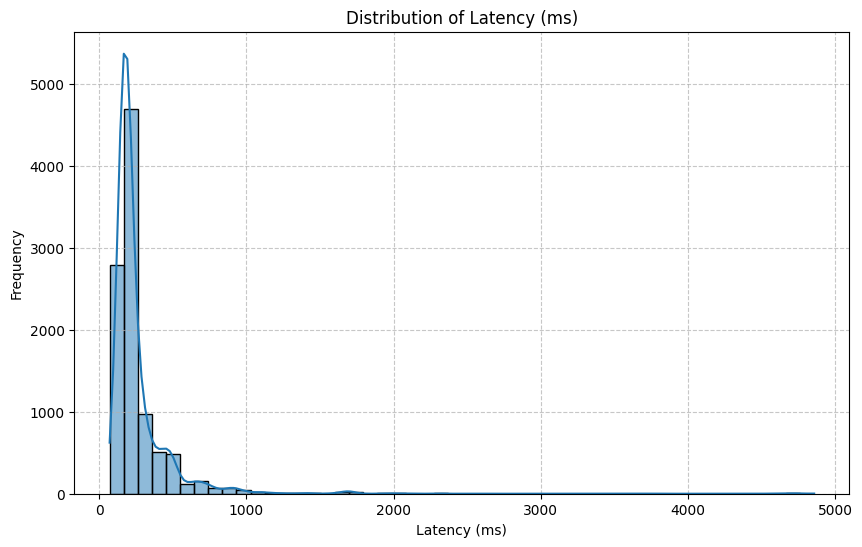

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'latency_ms' to numeric, handling potential errors
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')

# Drop rows where latency_ms couldn't be converted (NaNs)
df_cleaned = df.dropna(subset=['latency_ms'])


plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['latency_ms'], bins=50, kde=True)
plt.title('Distribution of Latency (ms)')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

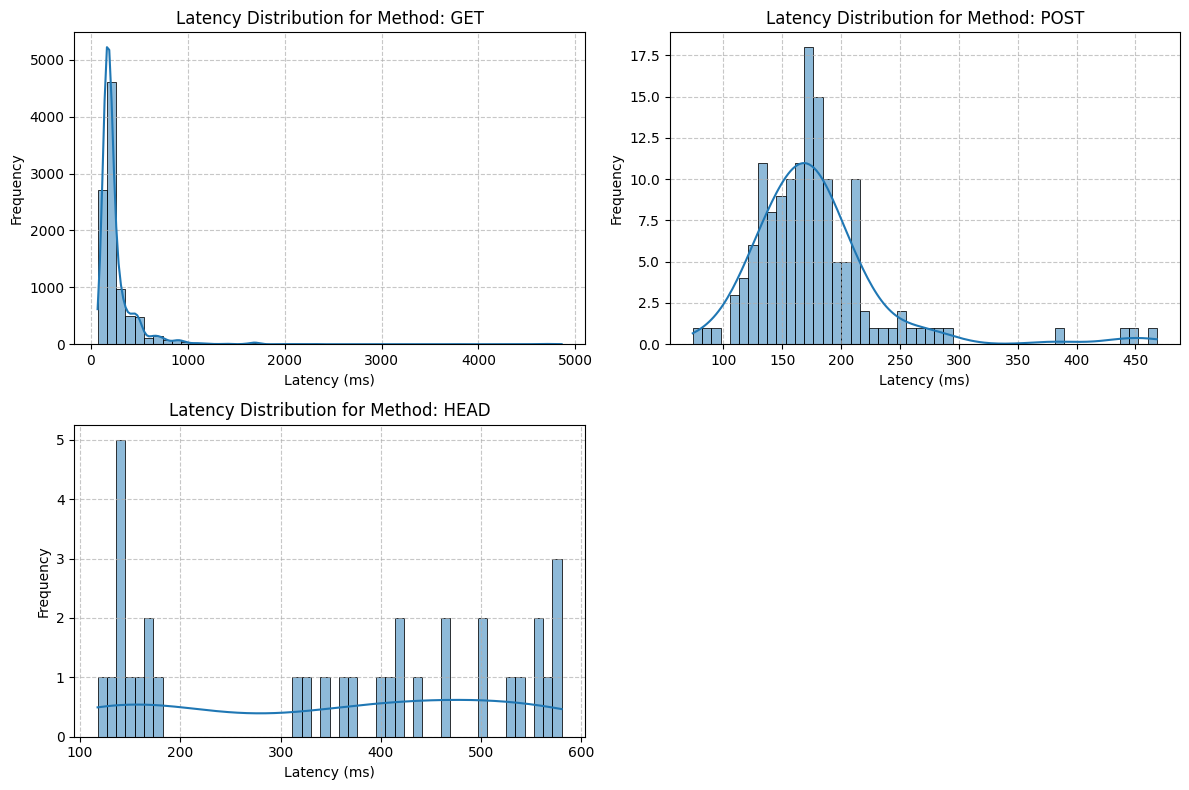

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique HTTP methods
http_methods = df_cleaned['method'].unique()

# Determine number of rows and columns for subplots
num_methods = len(http_methods)
num_cols = 2  # You can adjust this for desired layout
num_rows = (num_methods + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, method in enumerate(http_methods):
    plt.subplot(num_rows, num_cols, i + 1)
    method_df = df_cleaned[df_cleaned['method'] == method]
    sns.histplot(method_df['latency_ms'], bins=50, kde=True)
    plt.title(f'Latency Distribution for Method: {method}')
    plt.xlabel('Latency (ms)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

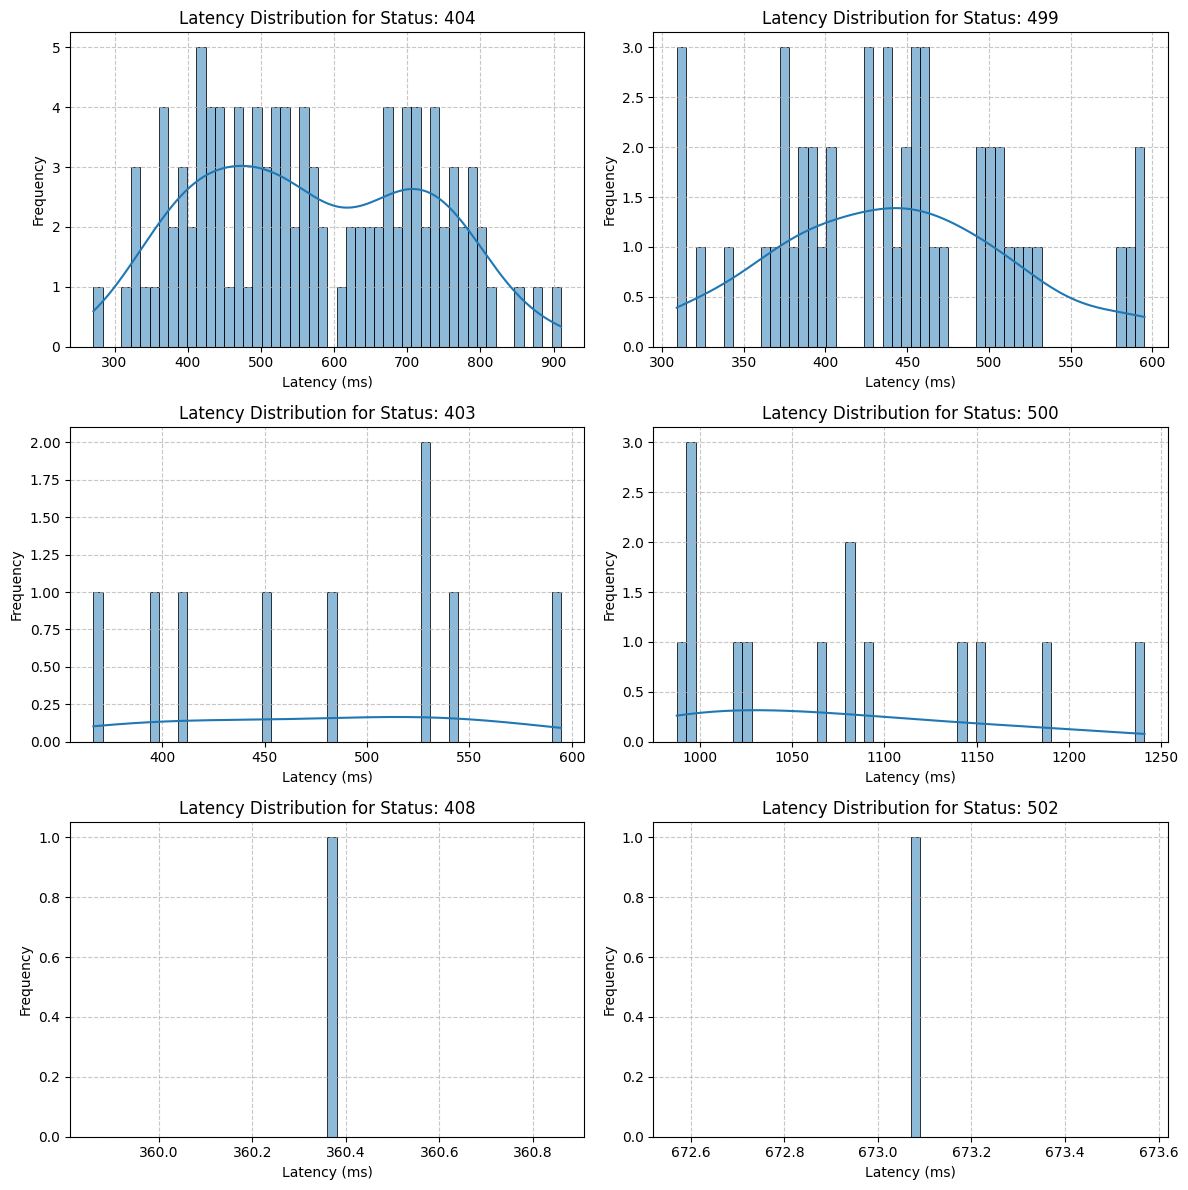

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'status' column is numeric and handle potential errors
df_cleaned['status'] = pd.to_numeric(df_cleaned['status'], errors='coerce')

# Filter for error status codes (4xx and 5xx)
error_df = df_cleaned[df_cleaned['status'].between(400, 599, inclusive='both')].copy()

# Convert status codes to integer type for display and grouping
error_df['status'] = error_df['status'].astype(int)

# Get unique HTTP error statuses
http_error_statuses = error_df['status'].unique()

# Determine number of rows and columns for subplots
num_errors = len(http_error_statuses)
num_cols = 2  # Adjust for desired layout
num_rows = (num_errors + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, status_code in enumerate(http_error_statuses):
    plt.subplot(num_rows, num_cols, i + 1)
    status_df = error_df[error_df['status'] == status_code]
    sns.histplot(status_df['latency_ms'], bins=50, kde=True)
    plt.title(f'Latency Distribution for Status: {status_code}')
    plt.xlabel('Latency (ms)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [19]:
# Calculate the 90th percentile of latency for each HTTP method
percentile_90_by_method = df_cleaned.groupby('method')['latency_ms'].quantile(0.90)

print("90th Percentile of Latency (ms) by HTTP Method:")
display(percentile_90_by_method)

90th Percentile of Latency (ms) by HTTP Method:


,latency_ms
method,
GET,460.264
HEAD,564.797
POST,216.638


In [20]:
# Get unique HTTP methods
http_methods = df_cleaned['method'].unique()

print("Requests with latency greater than the 90th percentile for each HTTP method:\n")

for method in http_methods:
    # Get the 90th percentile latency for the current method
    p90_latency = percentile_90_by_method.loc[method]

    # Filter requests for the current method that have latency greater than its 90th percentile
    high_latency_requests = df_cleaned[
        (df_cleaned['method'] == method) &
        (df_cleaned['latency_ms'] > p90_latency)
    ]


    print(f"--- Method: {method} (90th Percentile Latency: {p90_latency:.2f} ms) ---")
    if not high_latency_requests.empty:
        display(high_latency_requests[['ip', 'time', 'url', 'latency_ms']].head())
        print(f"Total high latency requests for {method}: {len(high_latency_requests)}\n")
    else:
        print(f"No requests found with latency greater than {p90_latency:.2f} ms for method {method}.\n")

Requests with latency greater than the 90th percentile for each HTTP method:

--- Method: GET (90th Percentile Latency: 460.26 ms) ---


,ip,time,url,latency_ms
1,5.210.140.170,23/Jan/2019:12:43:40 +0330,/apple-touch-icon-120x120.png,796.76
4,5.208.174.46,23/Jan/2019:22:52:04 +0330,/image/1221/mainSlideMobile,723.51
13,5.115.104.233,22/Jan/2019:20:38:19 +0330,/static/css/font_awesome/fonts/fontawesome-web...,831.94
55,40.77.167.205,26/Jan/2019:02:34:25 +0330,"/filter/b131,b144,b400",460.76
64,89.235.86.91,22/Jan/2019:10:02:37 +0330,/image/8722/specialSale,483.67


Total high latency requests for GET: 983

--- Method: POST (90th Percentile Latency: 216.64 ms) ---


,ip,time,url,latency_ms
424,84.241.18.24,26/Jan/2019:16:10:32 +0330,"/ajaxFilter/p3,rf8420000,rt112377000?page=1",239.82
830,151.239.241.163,26/Jan/2019:13:37:33 +0330,/orderAdministration/act/187970,232.39
993,195.181.169.141,22/Jan/2019:14:12:31 +0330,/orderAdministration/list/transmitted,226.87
1673,65.49.68.200,24/Jan/2019:10:12:19 +0330,/order/track,468.14
1697,91.99.30.32,23/Jan/2019:13:59:08 +0330,/orderAdministration/act/187687,267.61


Total high latency requests for POST: 15

--- Method: HEAD (90th Percentile Latency: 564.80 ms) ---


,ip,time,url,latency_ms
2863,5.122.185.0,22/Jan/2019:17:15:14 +0330,/amp_preconnect_polyfill_404_or_other_error_ex...,575.66
6025,91.92.185.227,25/Jan/2019:22:28:18 +0330,/amp_preconnect_polyfill_404_or_other_error_ex...,573.61
8946,5.117.138.143,24/Jan/2019:00:55:24 +0330,/amp_preconnect_polyfill_404_or_other_error_ex...,566.87
9154,83.120.83.24,24/Jan/2019:09:09:44 +0330,/amp_preconnect_polyfill_404_or_other_error_ex...,580.42


Total high latency requests for HEAD: 4

